# Lyric Semantic Search — a study of three ways to search song lyrics

**YDL 2026 · Applied NLP · Day 2 Lab Project**

We take ~57k English songs, split every song's lyrics into single lines, and search those lines three ways,
plus a hybrid. This notebook is the **lab report**: we explore the data, look inside the embeddings, then
**measure** how each method behaves — including a retrieval experiment under misspelled queries.

| Method | What it compares | Technique | Strong at |
|--------|------------------|-----------|-----------|
| **smart** | a **blend** of meaning + words | 0.65·GloVe + 0.35·tf-idf (fuzzy fallback) | general purpose |
| **tf-idf** | matching **words** | tf-idf + cosine | exact words |
| **GloVe** | the **meaning** of a line | SIF embeddings (idf-weighted + common-component removal) | synonyms, mood |
| **trigram** | **3-character chunks** (lon·ond·ndo·don) | char-3gram + cosine | typos, fuzzy |

> No heavy models (no BERT/Gemma) — only Day-2 tools: tokenization, tf-idf, pretrained word embeddings,
> cosine similarity, character n-grams, and a little PCA (for the SIF common component).

**Note on the corpus:** we search the **lyric text itself** (one line per document). The artist and song
title are only labels showing where each line came from — we do **not** search by title or author.

## 0. Load the indexes

In [1]:
import search   # search_smart / search_tfidf / search_glove / search_trigram / compare
search._load()
print(f"lines in corpus:   {len(search._lines):,}")
print(f"tf-idf vocab:      {len(search._tfidf.vocabulary_):,} words")
print(f"GloVe matrix:      {search._gmat.shape[0]:,} lines x {search._gmat.shape[1]}d")
print(f"trigram vocab:     {len(search._tri.vocabulary_):,} character 3-grams")

lines in corpus:   180,483
tf-idf vocab:      15,398 words
GloVe matrix:      180,483 lines x 100d
trigram vocab:     10,049 character 3-grams


## 1. Exploratory data analysis

Before modelling, look at the corpus: how long are lines, who is in it, and how word frequencies behave.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt, numpy as np, pandas as pd, re, collections
plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})

full = pd.read_csv('data/spotify_millsongdata.csv')
L = search._lines
wc = L['line'].str.split().str.len()
print(f"Full dataset:    {len(full):,} songs available")
print(f"Working corpus:  {L['song'].nunique():,} songs sampled  ->  {len(L):,} unique lines")
print(f"Avg lines/song:  {len(L)/L['song'].nunique():.1f}")
print(f"Line length:     mean {wc.mean():.1f} words  (range {wc.min()}-{wc.max()})")

Full dataset:    57,650 songs available
Working corpus:  7,472 songs sampled  ->  180,483 unique lines
Avg lines/song:  24.2
Line length:     mean 7.1 words  (range 4-18)


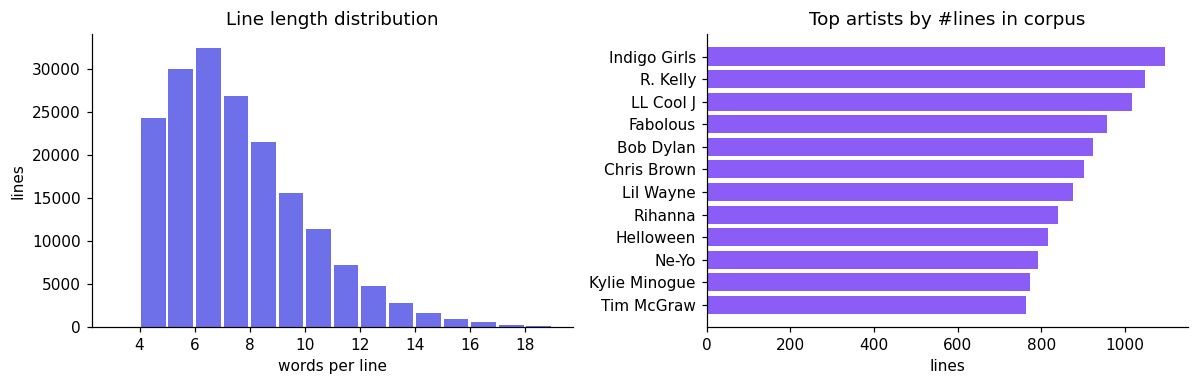

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(wc, bins=range(3, 20), color='#5457e6', alpha=.85, rwidth=.9)
ax[0].set_title('Line length distribution'); ax[0].set_xlabel('words per line'); ax[0].set_ylabel('lines')
top = L['artist'].value_counts().head(12)[::-1]
ax[1].barh(top.index, top.values, color='#8b5cf6')
ax[1].set_title('Top artists by #lines in corpus'); ax[1].set_xlabel('lines')
plt.tight_layout(); plt.show()

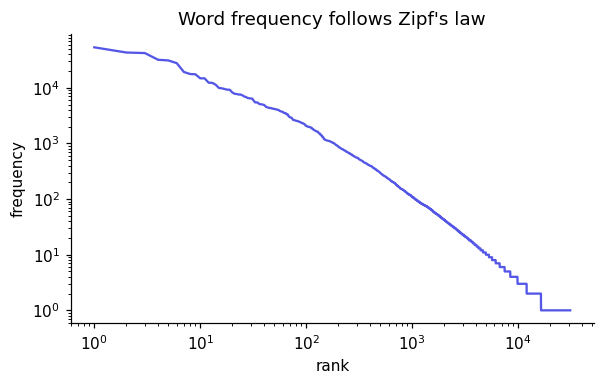

vocabulary: 31,112 unique tokens | most common: ['the', 'i', 'you', 'and', 'to', 'a', 'me', 'in']


In [4]:
tokc = collections.Counter()
for ln in L['line']:
    tokc.update(re.findall(r"[a-z']+", ln.lower()))
freqs = np.array(sorted(tokc.values(), reverse=True))
plt.figure(figsize=(5.6, 3.6))
plt.loglog(np.arange(1, len(freqs) + 1), freqs, color='#5457e6')
plt.title("Word frequency follows Zipf's law"); plt.xlabel('rank'); plt.ylabel('frequency')
plt.tight_layout(); plt.show()
print(f"vocabulary: {len(tokc):,} unique tokens | most common: {[w for w,_ in tokc.most_common(8)]}")

The frequency curve is a near-straight line on a log-log plot — **Zipf's law**. A few filler words
(*the, you, and, …*) dominate everything. That is precisely why our meaning vector **down-weights words by
idf**: otherwise these fillers would drown out the content.

## 2. Inside the embeddings

GloVe places each word at a point in 100-d space. We sanity-check that the geometry encodes meaning:
nearest neighbours and the classic analogy. (Computed directly with NumPy over the GloVe matrix.)

In [5]:
wv = search._wv
Mn = wv.vectors / np.linalg.norm(wv.vectors, axis=1, keepdims=True)   # unit vectors

def neighbors(word, k=6):
    v = wv[word] / np.linalg.norm(wv[word])
    sims = Mn @ v
    return [wv.index_to_key[i] for i in np.argsort(-sims)[:k+1] if wv.index_to_key[i] != word][:k]

def analogy(a, b, c, k=5):
    v = wv[b] - wv[a] + wv[c]; v = v / np.linalg.norm(v)
    sims = Mn @ v; ban = {a, b, c}
    return [wv.index_to_key[i] for i in np.argsort(-sims)[:k+10] if wv.index_to_key[i] not in ban][:k]

for w in ['sad', 'love', 'ocean', 'whiskey']:
    print(f"{w:8} -> {', '.join(neighbors(w))}")
print()
print("king - man + woman   =", analogy('man', 'king', 'woman'))
print("paris - france + italy =", analogy('france', 'paris', 'italy'))

sad      -> sorry, awful, tragic, horrible, happy, heartbreaking
love     -> me, passion, my, life, dream, you
ocean    -> sea, waters, seas, coast, atlantic, pacific


whiskey  -> whisky, vodka, rum, malt, brandy, liquor

king - man + woman   = ['queen', 'monarch', 'throne', 'daughter', 'prince']


paris - france + italy = ['rome', 'milan', 'naples', 'venice', 'turin']


Neighbours are clean synonyms/associates and the analogies land on *queen* and *rome* — the embedding
space genuinely encodes meaning as geometry. Now the idf weights that turn words into a line vector:

In [6]:
widf = search._widf
print(f"{'word':12} idf-weight")
for w in ['the', 'you', 'and', 'love', 'night', 'heart', 'lonely', 'whiskey', 'galaxy', 'heartbroken']:
    print(f"{w:12} {widf.get(w, search._wdefault):5.2f}")
print("\n-> fillers (the/you/and) get tiny weights; rare content words get large ones.")

word         idf-weight
the           2.36
you           2.58
and           2.79
love          4.22
night         5.36
heart         5.29
lonely        6.84
whiskey       9.04
galaxy       10.71
heartbroken  12.41

-> fillers (the/you/and) get tiny weights; rare content words get large ones.


### The meaning vector, end to end

`_embed` = idf-weighted average of GloVe word vectors, minus the SIF common component, then L2-normalised.
This single vector is what both `smart` and `glove` rank with.

In [7]:
v = search._embed("feeling heartbroken and alone")
print("shape:", v.shape, "| L2 norm:", round(float((v*v).sum()**0.5), 3))
print("first 6 dims:", [round(float(x), 3) for x in v[:6]])

shape: (100,) | L2 norm: 1.0
first 6 dims: [0.054, 0.113, 0.141, -0.031, -0.19, 0.26]


## 3. Qualitative comparison

Queries written in **our own words** — no line contains them verbatim. `compare()` shows all four methods.

In [8]:
search.compare("feeling heartbroken and alone")


Query: "feeling heartbroken and alone"

  ── smart    (hybrid)   ──
     0.81  "Why you're feeling so alone"  — Free, Catch A Train
     0.79  "You're feeling all alone"  — Glee, I'll Stand By You
     0.76  "Baby, I'm feeling, I'm feeling"  — Ten Years After, If You Should Love Me
     0.76  "That's why I'm feeling"  — Jennifer Lopez, Feelin' So Good
     0.76  "is you feeling me?"  — P!nk, Samuel

  ── tf-idf   (keywords) ──
     1.00  "There's a feeling I have"  — Madonna, Like A Flower
     1.00  "Can you see what I'm feeling?"  — Wilson Phillips, The Dream Is Still Alive
     1.00  "There's a feeling you give me"  — Willie Nelson, Be There For You
     1.00  "More than a feeling"  — Westlife, Lighthouse
     1.00  "I get a feeling in me"  — Alison Krauss, Oh, Atlanta

  ── GloVe    (meaning)  ──
     0.78  "When I'm feeling scared and lonely"  — Kylie Minogue, Count The Days
     0.78  "Heartbroken when you left my world"  — Usher, Throwback
     0.76  "When you're feeling lonely

     0.59  "Heartbroken when you left my world"  — Usher, Throwback
     0.56  "Broken down and all alone"  — Hillsong, Glow
     0.53  "Tonight I'm all alone and broken hearted"  — George Jones, A Lifetime To Regret
     0.52  "Feeling sad and all alone"  — Britney Spears, Luv The Hurt Away
     0.52  "One more broken heart"  — Point Of Grace, One More Broken Heart


In [9]:
search.compare("a cold and lonely winter night")


Query: "a cold and lonely winter night"

  ── smart    (hybrid)   ──
     0.89  "On a cold winter night"  — Harry Belafonte, Glory Manger
     0.86  "A cold and lonely night"  — Phish, Icculus
     0.80  "On a cold winter's night"  — Olivia Newton-John, The First Noel
     0.79  "To keep you cold as winter"  — Eurythmics, Cool Blue
     0.78  "Little darling, it's been a long cold lonely winter"  — Demi Lovato, Here Comes The Sun

  ── tf-idf   (keywords) ──


     0.86  "On a cold winter night"  — Harry Belafonte, Glory Manger
     0.86  "On a cold winter's night"  — Olivia Newton-John, The First Noel
     0.81  "A cold and lonely night"  — Phish, Icculus
     0.77  "To keep you cold as winter"  — Eurythmics, Cool Blue
     0.74  "On a cold winter's night that was so deep"  — Weezer, The First Noel

  ── GloVe    (meaning)  ──


     0.91  "On a cold winter night"  — Harry Belafonte, Glory Manger
     0.89  "A cold and lonely night"  — Phish, Icculus
     0.87  "The cold and lonely nights,"  — Roxette, Like Lovers Do
     0.86  "While the cold winter waitin'"  — Mazzy Star, Rhymes Of An Hour
     0.85  "It was so cold and winter-dark"  — Tragically Hip, The Bear

  ── trigram  (fuzzy)    ──


     0.85  "A cold and lonely night"  — Phish, Icculus
     0.78  "On a cold winter night"  — Harry Belafonte, Glory Manger
     0.70  "The cold and lonely nights,"  — Roxette, Like Lovers Do
     0.67  "When nights are cold and lonely"  — Patsy Cline, Stand By Your Man
     0.67  "On a cold winter's night"  — Olivia Newton-John, The First Noel


### What happens with typos?

The misspelled query **"heartbrokn and lonley"**: tf-idf and GloVe fail (no exact words / not in vocab),
while **trigram** still finds the right lines through shared chunks. (`smart` only falls back to fuzzy when
*every* word is unembeddable, so a lightly-misspelled query can still slip past it — we measure this next.)

In [10]:
search.compare("heartbrokn and lonley")   # intentional typos


Query: "heartbrokn and lonley"

  ── smart    (hybrid)   ──
     0.65  "I'm Rockin' and rollin'"  — Deep Purple, A Castle Full Of Rascals
     0.65  "And 'round and 'round"  — Randy Travis, Everything And All
     0.65  "1 and 2 and 3 and 4"  — P!nk, Respect
     0.65  "We're floatin' 'round and 'round"  — Jimi Hendrix, You've Got Me Floating
     0.65  "Pretendin' cheatin' and lyin'"  — Cheap Trick, Walk Away

  ── tf-idf   (keywords) ──
     (no keyword overlap — nothing found)

  ── GloVe    (meaning)  ──
     1.00  "I'm Rockin' and rollin'"  — Deep Purple, A Castle Full Of Rascals
     1.00  "And 'round and 'round"  — Randy Travis, Everything And All
     1.00  "1 and 2 and 3 and 4"  — P!nk, Respect
     1.00  "We're floatin' 'round and 'round"  — Jimi Hendrix, You've Got Me Floating
     1.00  "Pretendin' cheatin' and lyin'"  — Cheap Trick, Walk Away

  ── trigram  (fuzzy)    ──


     0.44  "Heartbreak, heartbreak here I come."  — Nina Simone, Can't Get Out Of This Mood
     0.43  "Heartbroken when you left my world"  — Usher, Throwback
     0.41  "Are you a heartbreaker"  — P!nk, Heartbreaker
     0.39  "Heartbreak here I come."  — Nina Simone, Can't Get Out Of This Mood
     0.38  "And those heartbreaking things"  — David Bowie, I Keep Forgetting


## 4. Experiment: retrieval accuracy, exact vs. misspelled queries

A measurable test. Take 120 random lines. For each, query with **(a)** the exact line and **(b)** the line
with ~12% of characters corrupted. For every method, record the **rank** of the original line, then report
**Recall@1** (how often the correct line is ranked first). This quantifies the typo claim instead of asserting it.

In [11]:
import random
from sklearn.metrics.pairwise import cosine_similarity
S = search; random.seed(0)

def s_glove(q): return S._gmat @ S._embed(q)
def s_tfidf(q): return cosine_similarity(S._tfidf.transform([q]), S._tmat).ravel()
def s_tri(q):   return cosine_similarity(S._tri.transform([q.lower()]), S._trimat).ravel()
def s_smart(q):
    g = s_glove(q)
    return s_tri(q) if not np.any(g) else 0.65*g + 0.35*s_tfidf(q)

def rank_of(sc, t): return int((sc > sc[t]).sum()) + 1
def add_typos(s, rate=0.12):
    return ''.join(random.choice('abcdefghijklmnopqrstuvwxyz') if (ch.isalpha() and random.random() < rate)
                   else ch for ch in s)

methods = {'tf-idf': s_tfidf, 'GloVe': s_glove, 'smart': s_smart, 'trigram': s_tri}
idxs = random.sample(range(len(S._lines)), 120)
clean = {m: [] for m in methods}; typo = {m: [] for m in methods}
for ix in idxs:
    line = S._lines.iloc[ix]['line']; tline = add_typos(line)
    for nm, fn in methods.items():
        clean[nm].append(rank_of(fn(line), ix))
        typo[nm].append(rank_of(fn(tline), ix))

r1 = lambda R: {m: float(np.mean([r <= 1 for r in v])) for m, v in R.items()}
print("Recall@1  exact query:", {m: round(x, 2) for m, x in r1(clean).items()})
print("Recall@1  typo  query:", {m: round(x, 2) for m, x in r1(typo).items()})

Recall@1  exact query: {'tf-idf': 1.0, 'GloVe': 1.0, 'smart': 1.0, 'trigram': 1.0}
Recall@1  typo  query: {'tf-idf': 0.47, 'GloVe': 0.34, 'smart': 0.42, 'trigram': 0.95}


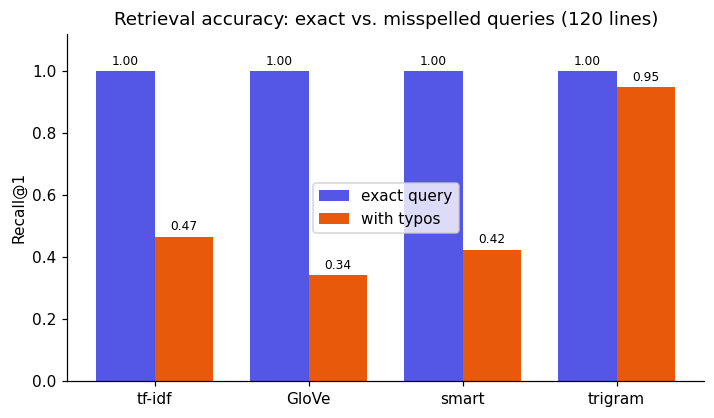

In [12]:
labels = list(methods); x = np.arange(len(labels)); w = 0.38
c1 = [np.mean([r <= 1 for r in clean[m]]) for m in labels]
t1 = [np.mean([r <= 1 for r in typo[m]]) for m in labels]
plt.figure(figsize=(6.6, 3.9))
plt.bar(x - w/2, c1, w, label='exact query', color='#5457e6')
plt.bar(x + w/2, t1, w, label='with typos',  color='#e8590c')
for i, (a, b) in enumerate(zip(c1, t1)):
    plt.text(i - w/2, a + .02, f'{a:.2f}', ha='center', fontsize=8)
    plt.text(i + w/2, b + .02, f'{b:.2f}', ha='center', fontsize=8)
plt.xticks(x, labels); plt.ylabel('Recall@1'); plt.ylim(0, 1.12)
plt.title('Retrieval accuracy: exact vs. misspelled queries (120 lines)')
plt.legend(); plt.tight_layout(); plt.show()

**Result.** On exact queries every method finds the line (Recall@1 ≈ 1.0). Under typos, **tf-idf and GloVe
collapse** (a corrupted word is a different token / out-of-vocabulary), and **only trigram stays high** (~0.95)
because character chunks survive misspellings.

A surprising, honest finding: **`smart` does *not* rescue typos here** (~0.42, near tf-idf). It only switches
to fuzzy when *all* words are out-of-vocabulary, but at ~12% character corruption many words are still partly
embeddable, so it stays in the meaning+keywords regime. Takeaway: smart is best for *clean* natural-language
queries; robust typo handling would need the **trigram signal mixed into smart** — a clear next improvement
the experiment points to.

## 5. A mood axis, and a map of the space

Embeddings let us build a **direction** for mood: average a few positive words minus a few negative ones.
Projecting every line onto that axis gives a sentiment score with no labelled data.

In [13]:
axis = S._embed("happy joyful love bright smile sunshine") - S._embed("sad lonely crying pain dark grief")
axis = axis / np.linalg.norm(axis)
val = S._gmat @ axis                      # mood score per line
order = np.argsort(val)
print("Most NEGATIVE lines:")
for i in order[:5]:        print(f"  {val[i]:+.2f}  \"{S._lines.iloc[i]['line']}\"")
print("\nMost POSITIVE lines:")
for i in order[::-1][:5]:  print(f"  {val[i]:+.2f}  \"{S._lines.iloc[i]['line']}\"")

Most NEGATIVE lines:
  -0.60  "Either way the victim dies in agonizing pain"
  -0.60  "I just can't shake the guilt or kill the pain"
  -0.58  "The suffering and the pain"
  -0.58  "One days suffering, pain and sorrow"
  -0.57  "(I'm killing all the pain)"

Most POSITIVE lines:
  +0.58  "Ready for the sunshine"
  +0.57  "Can't you see the sunshine"
  +0.53  "Let the sunshine, Let the sunshine in"
  +0.53  "I'm sippin' on sunshine"
  +0.53  "Sippin' on sunshine, sippin' on sunshine..."


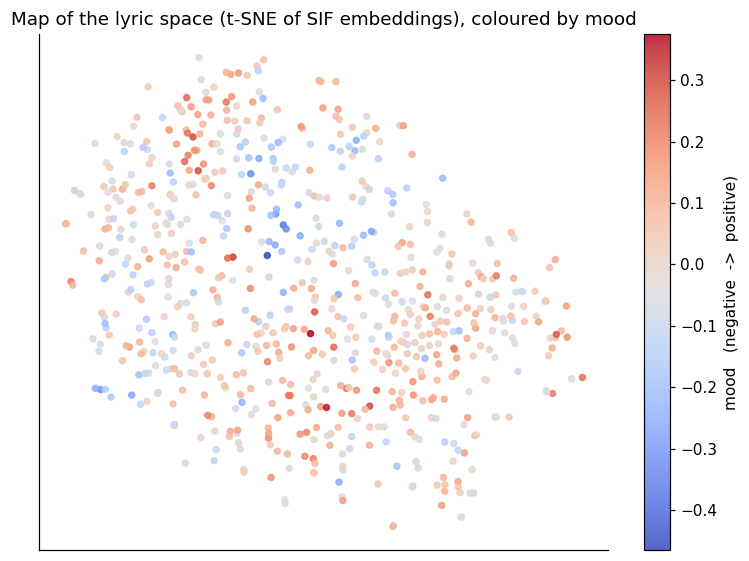

In [14]:
from sklearn.manifold import TSNE
random.seed(1)
samp = np.array(random.sample(range(len(S._lines)), 700))
xy = TSNE(n_components=2, metric='cosine', init='random', perplexity=30,
          random_state=42).fit_transform(S._gmat[samp])
plt.figure(figsize=(6.8, 5.2))
sc = plt.scatter(xy[:, 0], xy[:, 1], c=val[samp], cmap='coolwarm', s=15, alpha=.85)
plt.colorbar(sc, label='mood   (negative  ->  positive)')
plt.title('Map of the lyric space (t-SNE of SIF embeddings), coloured by mood')
plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

The mood axis cleanly separates grief from joy, and on the t-SNE map colour (mood) varies **smoothly**
across neighbourhoods — nearby lines share a vibe. Same geometry the search relies on, made visible.

## 6. Interactive artifact (3 search modes + a game)

`artifacts/search.html` — a standalone page: switch Smart / Meaning / Keywords / Fuzzy, watch the live
pipeline panel, click a result to read full lyrics, or play "Guess the Song". All in-browser, no server.

In [15]:
from IPython.display import IFrame
IFrame("artifacts/search.html", width="100%", height=640)

## 7. Findings

- The corpus obeys **Zipf's law** — a few fillers dominate, which is exactly why idf-weighting the meaning
  vector matters.
- GloVe **neighbours and analogies** confirm the embeddings encode meaning as geometry.
- **Retrieval experiment:** exact queries are trivial for all methods (Recall@1 ≈ 1.0); under typos, tf-idf
  and GloVe drop sharply and **only trigram stays high** (~0.95). `smart` does *not* rescue partial typos
  (~0.42) because it falls back to fuzzy only when *every* word is unembeddable — a measured limitation that
  points to mixing the trigram signal into the hybrid.
- A simple **mood axis** built from a handful of anchor words orders lines from grief to joy, and the t-SNE
  map shows mood changing smoothly across the space.

**Limitations:** averaging ignores word order; static embeddings give one vector per word (no word sense);
the shipped page uses a 5k-line sample so it stays a single file.